In [1]:
import pickle
import numpy as np
from scipy.signal import welch
import matplotlib.pyplot as plt
from scipy.stats import linregress
from fooof import FOOOF

/var/folders/pc/kr77rnc562z4p366739tyz6w0000gn/T/ipykernel_2075/3787181349.py:6: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


In [4]:

with open('/Users/bowmannovey/Desktop/Gangully_Proj/Decay/long_data.pkl', 'rb') as f:
    long_data = pickle.load(f)

# Flatten all days into one dict
all_long_combined = {}
for date_folder, sessions in long_data.items():
    for session, files in sessions.items():
        key = f"{date_folder}/{session}"
        all_long_combined[key] = files

print(f"Combined: {len(all_long_combined)} sessions, {sum(len(v) for v in all_long_combined.values())} files")

Combined: 18 sessions, 366 files


In [3]:
with open('short_data.pkl', 'rb') as f:
    short_data = pickle.load(f)


In [8]:
all_long_combined["20220309/111051"]["Data0001.mat"]["BroadbandData"][0].shape


(128, 200)

In [5]:
all_long_combined["20220309/111051"]["Data0001.mat"]["Params"]["Fs"]

array([[1000.]])

In [ ]:
def plot_power_spectrum(all_data, channel=1, fs=1000, title='Power Spectrum'):
    """
    Plot PSD from BroadbandData for a given channel.
    Concatenates all time bins across all trials into one continuous signal,
    then computes PSD via Welch's method.
    
    channel: 1-indexed channel number (1-128)
    fs: sampling rate in Hz
    """
    signal_chunks = []

    for subj_id, subj_files in all_data.items():
        for fname, mat_file in subj_files.items():
            file_data = []
            broadband = mat_file.get('BroadbandData')
            if broadband is None:
                continue
            
            # Since broadband lists bins shaped (128, ~200), we just extract 
            # the row corresponding to the chosen channel from each bin!
            for bin_data in broadband:
                file_data.append()

    # Concatenate all the 1D chunks sequentially into one continuous line
    signal = np.concatenate(signal_chunks)

    freqs, psd = welch(signal, fs=fs, nperseg=6667)

    plt.figure(figsize=(10, 5))
    plt.semilogy(freqs, psd)
    # plt.xlim([0, 200]) # if you still want this
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Power Spectral Density (µV²/Hz)')
    plt.title(f'{title} - Channel {channel}')
    plt.xlim([0, 200])
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_power_spectrum(short_data, channel=1, title='Short Exposure')



IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [ ]:
def plot_power_corrected(
    all_data,
    channel=6,
    fs=1000,
    nperseg=6667,
    title='Power Spectrum',
    fit_range=(1, 200),
    line_freq=60,
    line_exclusion_hz=2,
):
    """
    Plot PSD with 1/f correction for a given channel.

    The 1/f slope is fit in log-log space across the entire frequency range
    (default 1-200 Hz) to get a broadband average 1/f baseline.
    """
    n_channels = 128
    signal_chunks = []

    for subj_id, subj_files in all_data.items():
        for fname, mat_file in subj_files.items():
            broadband = mat_file['BroadbandData']
            for bin_data in broadband:
                n_samples = len(bin_data) // n_channels
                reshaped = bin_data[:n_channels * n_samples].reshape(n_channels, n_samples)
                signal_chunks.append(reshaped[channel - 1, :])

    signal = np.concatenate(signal_chunks)
    print(f"Total signal length: {len(signal)} samples ({len(signal)/fs:.1f} seconds)")

    freqs, psd = welch(signal, fs=fs, nperseg=nperseg)

    mask = freqs > 0
    freqs_pos = freqs[mask]
    psd_pos = psd[mask]

    log_freqs = np.log10(freqs_pos)
    log_psd = np.log10(psd_pos)

    fit_mask = (freqs_pos >= fit_range[0]) & (freqs_pos <= fit_range[1])

    if line_freq is not None and line_freq > 0:
        max_harmonic = int(freqs_pos.max() // line_freq)
        for k in range(1, max_harmonic + 1):
            harmonic = k * line_freq
            fit_mask &= np.abs(freqs_pos - harmonic) > line_exclusion_hz

    if np.sum(fit_mask) < 2:
        raise ValueError(
            f"Not enough points for 1/f fit. Check fit_range={fit_range} and exclusions."
        )

    slope, intercept, r, p, se = linregress(log_freqs[fit_mask], log_psd[fit_mask])
    fit_line = slope * log_freqs + intercept

    corrected_db = 10 * (log_psd - fit_line)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].loglog(freqs_pos, psd_pos)
    axes[0].set_xlabel('Frequency (Hz)')
    axes[0].set_ylabel('Power (µV²/Hz)')
    axes[0].set_title(f'Raw PSD - Ch {channel}')
    axes[0].set_xlim([0.5, 200])
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(log_freqs, log_psd, label='PSD')
    axes[1].plot(log_freqs, fit_line, 'r--', label=f'1/f fit ({fit_range[0]}-{fit_range[1]} Hz, slope={slope:.2f})')
    axes[1].set_xlabel('log10(Frequency)')
    axes[1].set_ylabel('log10(Power)')
    axes[1].set_title(f'PSD with 1/f fit - Ch {channel}')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(freqs_pos, corrected_db)
    axes[2].set_xlabel('Frequency (Hz)')
    axes[2].set_ylabel('Corrected Power (dB re 1/f)')
    axes[2].set_title(f'1/f Corrected - Ch {channel}')
    axes[2].set_xlim([0.5, 200])
    axes[2].axhline(0, color='k', linestyle='--', linewidth=0.5)
    axes[2].grid(True, alpha=0.3)

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

    print(f"Frequency resolution: {freqs[1] - freqs[0]:.3f} Hz")
    print(f"1/f slope: {slope:.3f}")
    print(f"1/f fit band: {fit_range[0]}-{fit_range[1]} Hz")

Total signal length: 1936610 samples (1936.6 seconds)


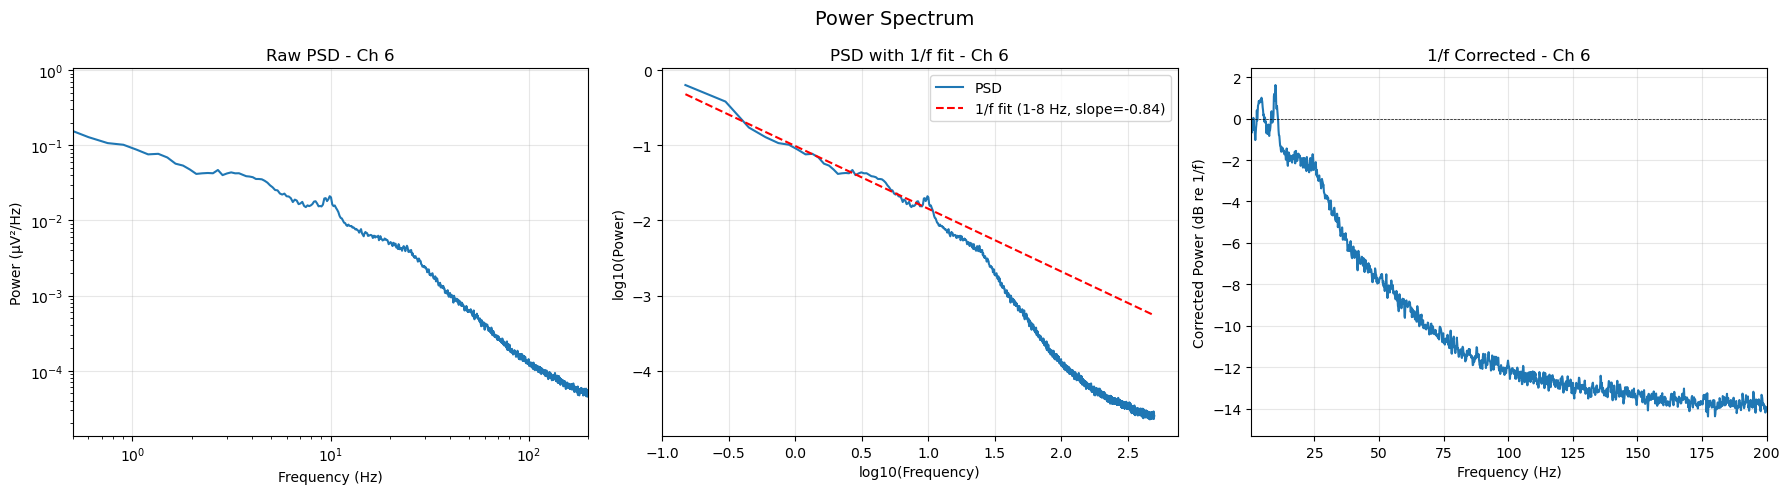

Frequency resolution: 0.150 Hz
1/f slope: -0.835
1/f fit band: 1-8 Hz


In [24]:
plot_power_corrected(all_long_combined)

In [25]:
def plot_power_average(
    all_data,
    fs=1000,
    nperseg=6667,
    output_dir=None,
    fit_range=(1, 200),
    line_freq=60,
    line_exclusion_hz=2,
):
    n_channels = 128
    ch_signals = {ch: [] for ch in range(n_channels)}

    for subj_id, subj_files in all_data.items():
        for fname, mat_file in subj_files.items():
            broadband = mat_file['BroadbandData']
            for bin_data in broadband:
                n_samp = len(bin_data) // n_channels
                reshaped = bin_data[:n_channels * n_samp].reshape(n_channels, n_samp)
                for ch in range(n_channels):
                    ch_signals[ch].append(reshaped[ch, :])

    all_psds = []
    for ch in range(n_channels):
        signal = np.concatenate(ch_signals[ch])
        freqs, psd = welch(signal, fs=fs, nperseg=nperseg)
        all_psds.append(psd)

    all_psds = np.array(all_psds)
    mean_psd = np.mean(all_psds, axis=0)

    mask = freqs > 0
    freqs_pos = freqs[mask]
    log_f = np.log10(freqs_pos)
    log_p = np.log10(mean_psd[mask])

    fit_mask = (freqs_pos >= fit_range[0]) & (freqs_pos <= fit_range[1])

    if line_freq is not None and line_freq > 0:
        max_harmonic = int(freqs_pos.max() // line_freq)
        for k in range(1, max_harmonic + 1):
            harmonic = k * line_freq
            fit_mask &= np.abs(freqs_pos - harmonic) > line_exclusion_hz

    if np.sum(fit_mask) < 2:
        raise ValueError(
            f"Not enough points for 1/f fit. Check fit_range={fit_range} and exclusions."
        )

    slope, intercept, _, _, _ = linregress(log_f[fit_mask], log_p[fit_mask])
    fit_line = slope * log_f + intercept
    corrected_db = 10 * (log_p - fit_line)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].loglog(freqs_pos, mean_psd[mask])
    axes[0].set_xlabel('Frequency (Hz)')
    axes[0].set_ylabel('Power (µV²/Hz)')
    axes[0].set_title('Raw PSD (mean across all channels)')
    axes[0].set_xlim([0.5, 200])
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(log_f, log_p, label='Log PSD')
    axes[1].plot(log_f, fit_line, 'r--', label=f'1/f fit ({fit_range[0]}-{fit_range[1]} Hz, slope={slope:.2f})')
    axes[1].set_xlabel('log10(Frequency)')
    axes[1].set_ylabel('log10(Power)')
    axes[1].set_title('Log Power + 1/f Fit (average)')
    axes[1].legend(loc='best')
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(freqs_pos, corrected_db)
    axes[2].set_xlabel('Frequency (Hz)')
    axes[2].set_ylabel('Corrected Power (dB re 1/f)')
    axes[2].set_title(f'1/f Corrected (slope={slope:.2f})')
    axes[2].set_xlim([0.5, 200])
    axes[2].axhline(0, color='k', linestyle='--', linewidth=0.5)
    axes[2].grid(True, alpha=0.3)

    fig.suptitle('Long Session - All Channels Averaged', fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if output_dir:
        fpath = os.path.join(output_dir, "Power_Average.png")
        plt.savefig(fpath, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Resolution: {freqs[1]-freqs[0]:.3f} Hz")
    print(f"1/f slope: {slope:.3f}")
    print(f"1/f fit band: {fit_range[0]}-{fit_range[1]} Hz")

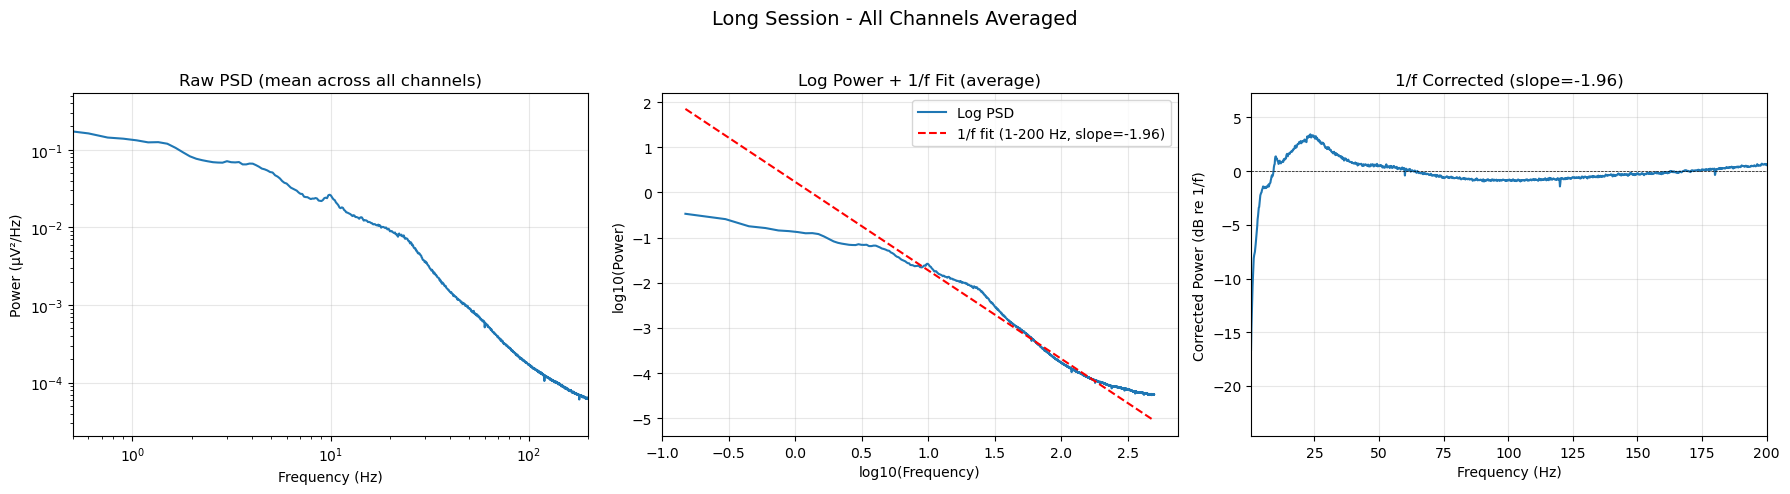

Resolution: 0.150 Hz
1/f slope: -1.959
1/f fit band: 1-200 Hz


In [26]:
plot_power_average(all_long_combined)

In [23]:
def get_bin_lengths(all_data, n_channels=128):
    """Collect bin lengths in samples-per-channel across all files."""
    lengths = []
    for subj_id, subj_files in all_data.items():
        for fname, mat_file in subj_files.items():
            for bin_data in mat_file['BroadbandData']:
                lengths.append(len(bin_data) // n_channels)
    return np.array(lengths, dtype=int)


def summarize_nperseg_choice(all_data, chosen_nperseg, n_channels=128):
    """Report how a user-chosen nperseg interacts with bin lengths."""
    bin_lengths = get_bin_lengths(all_data, n_channels=n_channels)
    if len(bin_lengths) == 0:
        raise ValueError('No bins found in dataset.')

    valid_bins = np.sum(bin_lengths >= chosen_nperseg)
    total_bins = len(bin_lengths)
    print(f'Bin length range: {bin_lengths.min()} to {bin_lengths.max()} samples/channel')
    print(f'Selected nperseg = {chosen_nperseg}')
    print(f'Valid bins: {valid_bins}/{total_bins} ({100 * valid_bins / total_bins:.1f}%)')
    print(f'Frequency resolution: {1000 / chosen_nperseg:.3f} Hz')
    return bin_lengths


def compute_file_psd(mat_file, channel=1, fs=1000, nperseg=6667, average_bins=True):
    """Compute PSD(s) for one file from BroadbandData using a fixed nperseg.

    If average_bins=True, returns one PSD averaged across valid bins in the file.
    Otherwise returns one PSD per valid bin.
    """
    n_channels = 128
    broadband = mat_file['BroadbandData']
    bin_psds = []
    freqs_ref = None
    skipped_bins = 0

    for bin_data in broadband:
        n_samples = len(bin_data) // n_channels
        if n_samples < nperseg:
            skipped_bins += 1
            continue

        reshaped = bin_data[: n_channels * n_samples].reshape(n_channels, n_samples)
        signal_1d = reshaped[channel - 1, :]
        freqs, psd = welch(signal_1d, fs=fs, nperseg=nperseg)

        if freqs_ref is None:
            freqs_ref = freqs
        elif len(freqs) != len(freqs_ref) or not np.allclose(freqs, freqs_ref):
            raise ValueError('Inconsistent frequency grids across bins even with fixed nperseg.')

        bin_psds.append(psd)

    if not bin_psds:
        raise ValueError(f'No valid bins for this file with nperseg={nperseg}.')

    bin_psds = np.array(bin_psds)

    if average_bins:
        return freqs_ref, np.mean(bin_psds, axis=0), skipped_bins, len(broadband)
    return freqs_ref, bin_psds, skipped_bins, len(broadband)


def collect_file_psds(all_data, channel=1, fs=1000, nperseg=6667):
    """Compute one PSD per file by averaging Welch PSDs across valid bins."""
    file_psds = []
    file_labels = []
    freqs_ref = None
    file_stats = []

    for subj_id, subj_files in all_data.items():
        for fname, mat_file in subj_files.items():
            try:
                freqs, mean_psd, skipped_bins, total_bins = compute_file_psd(
                    mat_file,
                    channel=channel,
                    fs=fs,
                    nperseg=nperseg,
                    average_bins=True,
                )
                if freqs_ref is None:
                    freqs_ref = freqs
                elif len(freqs) != len(freqs_ref) or not np.allclose(freqs, freqs_ref):
                    raise ValueError('Inconsistent frequency grids across files.')

                file_psds.append(mean_psd)
                label = f'{subj_id}/{fname}'
                file_labels.append(label)
                file_stats.append({
                    'label': label,
                    'used_bins': total_bins - skipped_bins,
                    'skipped_bins': skipped_bins,
                    'total_bins': total_bins,
                })
            except Exception as exc:
                print(f'Skipping {subj_id}/{fname}: {exc}')

    if not file_psds:
        raise ValueError('No PSDs were computed.')

    return freqs_ref, np.array(file_psds), file_labels, file_stats

In [26]:
# User-controlled Welch window length
selected_nperseg = 150
print(f'Selected nperseg = {selected_nperseg}')

Selected nperseg = 150


In [1]:
# Average PSD across files, then fit FOOOF to that average
channel = 2
bin_lengths = summarize_nperseg_choice(all_long_combined, selected_nperseg)
freqs_files, file_psds, file_labels, file_stats = collect_file_psds(
    all_long_combined,
    channel=channel,
    nperseg=selected_nperseg,
)
mean_file_psd = np.mean(file_psds, axis=0)
std_file_psd = np.std(file_psds, axis=0)

used_bins = sum(item['used_bins'] for item in file_stats)
skipped_bins = sum(item['skipped_bins'] for item in file_stats)
total_bins = sum(item['total_bins'] for item in file_stats)

# Match peak width limits to spectral resolution
freq_resolution = 1000 / selected_nperseg
peak_width_low = max(2 * freq_resolution, 2.0)
peak_width_high = max(peak_width_low + 2.0, 12.0)

fm_avg = FOOOF(
    peak_width_limits=[peak_width_low, peak_width_high],
    max_n_peaks=6,
    min_peak_height=0.1,
)
fm_avg.fit(freqs_files, mean_file_psd, freq_range=[1, 200])

print(f'Computed PSDs for {len(file_labels)} files on channel {channel}')
print(f'Selected nperseg used: {selected_nperseg}')
print(f'Used bins: {used_bins}/{total_bins} | Skipped bins: {skipped_bins}')
print(f'FOOOF peak width limits: [{peak_width_low:.2f}, {peak_width_high:.2f}] Hz')
print('Average-PSD aperiodic params:', fm_avg.get_params('aperiodic_params'))
print('Average-PSD peak params:')
print(fm_avg.get_params('peak_params'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].loglog(freqs_files, mean_file_psd, color='k', label='Mean PSD across files')
axes[0].fill_between(
    freqs_files,
    np.maximum(mean_file_psd - std_file_psd, 1e-20),
    mean_file_psd + std_file_psd,
    color='gray',
    alpha=0.25,
    label='±1 SD across files',
)
axes[0].set_xlim([1, 200])
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Power')
axes[0].set_title('Average PSD Across Files')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

fm_avg.plot(plot_peaks='shade', add_legend=True, ax=axes[1])
axes[1].set_title('FOOOF Fit to Average PSD')
plt.tight_layout()
plt.show()

NameError: name 'summarize_nperseg_choice' is not defined

FOOOF failed for 20220429/105659/Data0018.mat: too many indices for array: array is 1-dimensional, but 2 were indexed
Successfully fit FOOOF on 365 files
FOOOF peak width limits: [13.33, 15.33] Hz
Mean exponent: 1.740 +/- 0.132
Files with gamma peaks (70-150 Hz): 148/365
Mean gamma peak power: 0.189 +/- 0.060


FOOOF failed for 20220429/105659/Data0018.mat: too many indices for array: array is 1-dimensional, but 2 were indexed
Successfully fit FOOOF on 365 files
FOOOF peak width limits: [13.33, 15.33] Hz
Mean exponent: 1.740 +/- 0.132
Files with gamma peaks (70-150 Hz): 148/365
Mean gamma peak power: 0.189 +/- 0.060


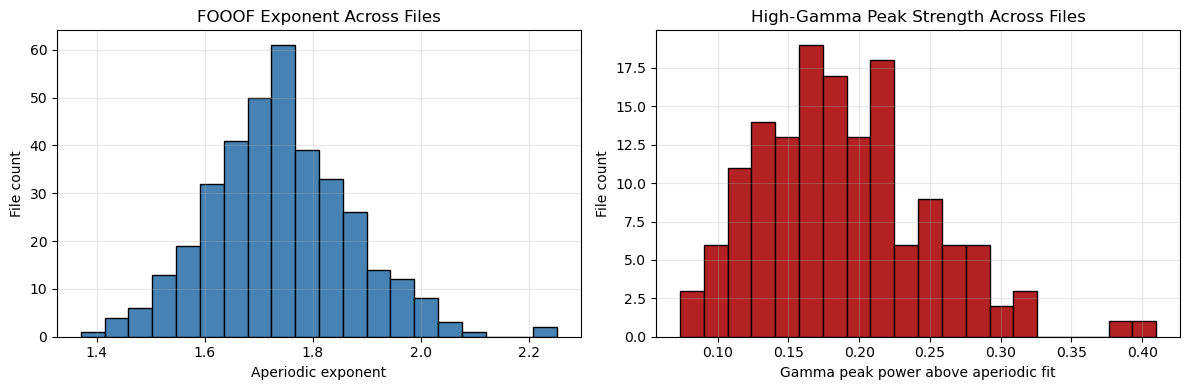


Top files by gamma peak power:
20220427/104443/Data0007.mat: gamma_cf=134.18 Hz, gamma_power=0.410, exponent=1.600, R2=0.990
20220309/111051/Data0021.mat: gamma_cf=143.57 Hz, gamma_power=0.379, exponent=1.587, R2=0.965
20220309/111313/Data0003.mat: gamma_cf=122.41 Hz, gamma_power=0.314, exponent=1.612, R2=0.979
20220309/111051/Data0014.mat: gamma_cf=136.00 Hz, gamma_power=0.314, exponent=1.744, R2=0.988
20220427/104824/Data0006.mat: gamma_cf=122.14 Hz, gamma_power=0.310, exponent=1.701, R2=0.991
20220309/111051/Data0019.mat: gamma_cf=134.85 Hz, gamma_power=0.303, exponent=1.876, R2=0.976
20220429/105659/Data0012.mat: gamma_cf=149.81 Hz, gamma_power=0.299, exponent=1.850, R2=0.985
20220427/103604/Data0012.mat: gamma_cf=130.32 Hz, gamma_power=0.290, exponent=1.445, R2=0.973
20220316/105537/Data0002.mat: gamma_cf=147.26 Hz, gamma_power=0.287, exponent=1.791, R2=0.989
20220429/105659/Data0010.mat: gamma_cf=143.52 Hz, gamma_power=0.286, exponent=1.837, R2=0.975


In [28]:
# Fit FOOOF per file and summarize across files
per_file_results = []

freq_resolution = 1000 / selected_nperseg
peak_width_low = max(2 * freq_resolution, 2.0)
peak_width_high = max(peak_width_low + 2.0, 12.0)

for label, file_psd in zip(file_labels, file_psds):
    fm_file = FOOOF(
        peak_width_limits=[peak_width_low, peak_width_high],
        max_n_peaks=6,
        min_peak_height=0.1,
    )
    try:
        fm_file.fit(freqs_files, file_psd, freq_range=[1, 200])
        ap_params = fm_file.get_params('aperiodic_params')
        peak_params = fm_file.get_params('peak_params')

        gamma_peak_power = np.nan
        gamma_peak_cf = np.nan
        if peak_params is not None and len(peak_params) > 0:
            gamma_peaks = peak_params[(peak_params[:, 0] >= 70) & (peak_params[:, 0] <= 150)]
            if len(gamma_peaks) > 0:
                best_peak = gamma_peaks[np.argmax(gamma_peaks[:, 1])]
                gamma_peak_cf = best_peak[0]
                gamma_peak_power = best_peak[1]

        per_file_results.append({
            'label': label,
            'offset': ap_params[0],
            'exponent': ap_params[-1],
            'n_peaks': 0 if peak_params is None else len(peak_params),
            'gamma_peak_cf': gamma_peak_cf,
            'gamma_peak_power': gamma_peak_power,
            'r_squared': fm_file.r_squared_,
            'error': fm_file.error_,
        })
    except Exception as exc:
        print(f'FOOOF failed for {label}: {exc}')

print(f'Successfully fit FOOOF on {len(per_file_results)} files')
print(f'FOOOF peak width limits: [{peak_width_low:.2f}, {peak_width_high:.2f}] Hz')

if per_file_results:
    exponents = np.array([row['exponent'] for row in per_file_results], dtype=float)
    gamma_powers = np.array([row['gamma_peak_power'] for row in per_file_results], dtype=float)
    valid_gamma = np.isfinite(gamma_powers)

    print(f"Mean exponent: {np.nanmean(exponents):.3f} +/- {np.nanstd(exponents):.3f}")
    print(f"Files with gamma peaks (70-150 Hz): {np.sum(valid_gamma)}/{len(gamma_powers)}")
    if np.any(valid_gamma):
        print(f"Mean gamma peak power: {np.nanmean(gamma_powers[valid_gamma]):.3f} +/- {np.nanstd(gamma_powers[valid_gamma]):.3f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(exponents, bins=20, color='steelblue', edgecolor='black')
    axes[0].set_xlabel('Aperiodic exponent')
    axes[0].set_ylabel('File count')
    axes[0].set_title('FOOOF Exponent Across Files')
    axes[0].grid(True, alpha=0.3)

    axes[1].hist(gamma_powers[valid_gamma], bins=20, color='firebrick', edgecolor='black')
    axes[1].set_xlabel('Gamma peak power above aperiodic fit')
    axes[1].set_ylabel('File count')
    axes[1].set_title('High-Gamma Peak Strength Across Files')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    top_gamma = sorted(
        [row for row in per_file_results if np.isfinite(row['gamma_peak_power'])],
        key=lambda row: row['gamma_peak_power'],
        reverse=True,
    )[:10]
    print('\nTop files by gamma peak power:')
    for row in top_gamma:
        print(
            f"{row['label']}: gamma_cf={row['gamma_peak_cf']:.2f} Hz, "
            f"gamma_power={row['gamma_peak_power']:.3f}, exponent={row['exponent']:.3f}, "
            f"R2={row['r_squared']:.3f}"
        )

/var/folders/pc/kr77rnc562z4p366739tyz6w0000gn/T/ipykernel_87503/4110244033.py:21: RuntimeWarning: divide by zero encountered in log10
  ap_log_file = offset - exponent * np.log10(freqs_files)
/var/folders/pc/kr77rnc562z4p366739tyz6w0000gn/T/ipykernel_87503/4110244033.py:21: RuntimeWarning: divide by zero encountered in log10
  ap_log_file = offset - exponent * np.log10(freqs_files)
/var/folders/pc/kr77rnc562z4p366739tyz6w0000gn/T/ipykernel_87503/4110244033.py:21: RuntimeWarning: divide by zero encountered in log10
  ap_log_file = offset - exponent * np.log10(freqs_files)
/var/folders/pc/kr77rnc562z4p366739tyz6w0000gn/T/ipykernel_87503/4110244033.py:21: RuntimeWarning: divide by zero encountered in log10
  ap_log_file = offset - exponent * np.log10(freqs_files)
/var/folders/pc/kr77rnc562z4p366739tyz6w0000gn/T/ipykernel_87503/4110244033.py:21: RuntimeWarning: divide by zero encountered in log10
  ap_log_file = offset - exponent * np.log10(freqs_files)
/var/folders/pc/kr77rnc562z4p366739

Computed average residual curve from 366 files
Selected nperseg used: 150
FOOOF peak width limits: [13.33, 15.33] Hz
High-gamma mean distance: -0.039 dB
High-gamma peak mean distance: 0.547 dB


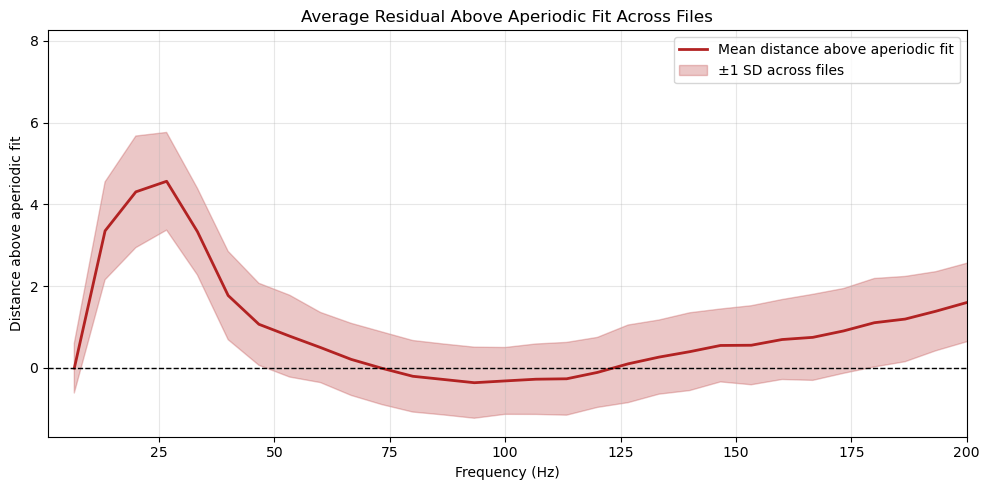

In [31]:
# Average residual above the aperiodic fit across files, with ±1 SD
residual_curves_db = []
used_labels = []

freq_resolution = 1000 / selected_nperseg
peak_width_low = max(2 * freq_resolution, 2.0)
peak_width_high = max(peak_width_low + 2.0, 12.0)

for label, file_psd in zip(file_labels, file_psds):
    fm_file = FOOOF(
        peak_width_limits=[peak_width_low, peak_width_high],
        max_n_peaks=6,
        min_peak_height=0.1,
    )
    try:
        fm_file.fit(freqs_files, file_psd, freq_range=[1, 200])
        ap_params = fm_file.get_params('aperiodic_params')

        if len(ap_params) == 2:
            offset, exponent = ap_params
            ap_log_file = offset - exponent * np.log10(freqs_files)
        elif len(ap_params) == 3:
            offset, knee, exponent = ap_params
            ap_log_file = offset - np.log10(knee + freqs_files**exponent)
        else:
            raise ValueError(f'Unexpected aperiodic params: {ap_params}')

        resid_db_file = 10 * (np.log10(file_psd) - ap_log_file)
        residual_curves_db.append(resid_db_file)
        used_labels.append(label)
    except Exception as exc:
        print(f'Skipping residual curve for {label}: {exc}')

residual_curves_db = np.array(residual_curves_db)
mean_resid_db = np.mean(residual_curves_db, axis=0)
std_resid_db = np.std(residual_curves_db, axis=0)

hg_mask = (freqs_files >= 70) & (freqs_files <= 150)
for harmonic in [60, 120, 180]:
    hg_mask &= np.abs(freqs_files - harmonic) > 2

print(f'Computed average residual curve from {len(used_labels)} files')
print(f'Selected nperseg used: {selected_nperseg}')
print(f'FOOOF peak width limits: [{peak_width_low:.2f}, {peak_width_high:.2f}] Hz')
print(f'High-gamma mean distance: {np.mean(mean_resid_db[hg_mask]):.3f} dB')
print(f'High-gamma peak mean distance: {np.max(mean_resid_db[hg_mask]):.3f} dB')

plt.figure(figsize=(10, 5))
plt.plot(freqs_files, mean_resid_db, color='firebrick', linewidth=2, label='Mean distance above aperiodic fit')
plt.fill_between(
    freqs_files,
    mean_resid_db - std_resid_db,
    mean_resid_db + std_resid_db,
    color='firebrick',
    alpha=0.25,
    label='±1 SD across files',
)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlim([1, 200])
plt.xlabel('Frequency (Hz)')
plt.ylabel('Distance above aperiodic fit')
plt.title('Average Residual Above Aperiodic Fit Across Files')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Processed 366 full continuous trials.


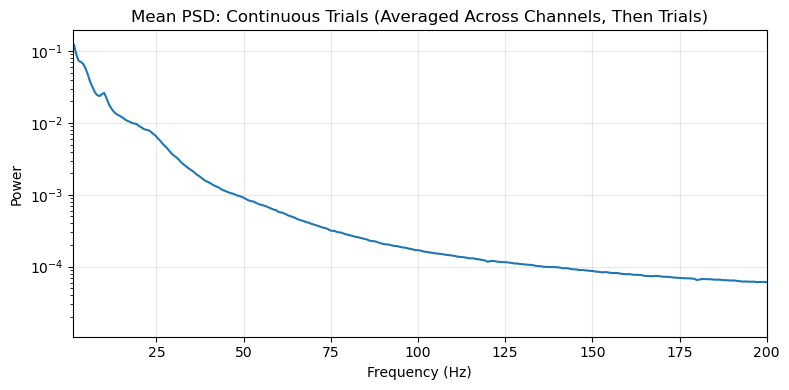

In [13]:
# Data already loaded earlier in your notebook
all_data = all_long_combined  # or short_data

fs = 1000
n_channels = 128
nperseg = 1500 # 1.5-second Welch window for better than 1Hz resolution

all_trial_psds = [] 
freqs_ref = None

for subj_files in all_data.values():
    for mat_file in subj_files.values():
        broadband = mat_file.get("BroadbandData")
            
        # 1. CONCATENATE all 40 bins together into ONE continuous trial.
        # Since broadband is already a list of (128, 200) arrays, axis=1 stitches time horizontally
        full_trial_signal = np.concatenate(broadband, axis=1) 
        # print(f'full trial shape : {full_trial_signal[0].shape}')
                    
        # 2. Calculate PSD on the full concatenated trial (for each channel)
        ch_psds = []
        for ch in range(n_channels):
            # full_trial_signal[ch] gives the ~8-sec continuous line for a single channel
            freqs, psd = welch(full_trial_signal[ch], fs=fs, nperseg=nperseg)
            ch_psds.append(psd)
            
        # 3. Average across all 128 channels for THIS single trial
        trial_mean_psd = np.mean(ch_psds, axis=0) 
        all_trial_psds.append(trial_mean_psd)
        
        if freqs_ref is None:
            freqs_ref = freqs

print(f"Processed {len(all_trial_psds)} full continuous trials.")

# 4. Average across all trials to get final spectrum
mean_psd = np.mean(all_trial_psds, axis=0)

# Overwrite trial_psds so the FOOOF ±1 SD cell directly below continues to work!
trial_psds = all_trial_psds 

plt.figure(figsize=(8, 4))
plt.semilogy(freqs_ref, mean_psd)
plt.xlim(1, 200)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Mean PSD: Continuous Trials (Averaged Across Channels, Then Trials)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 1.00 <= 0.67
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 1.00 <= 0.67
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

                                                                                                  
                                   FOOOF - POWER SPECTRUM MODEL                                   
                                                                                                  

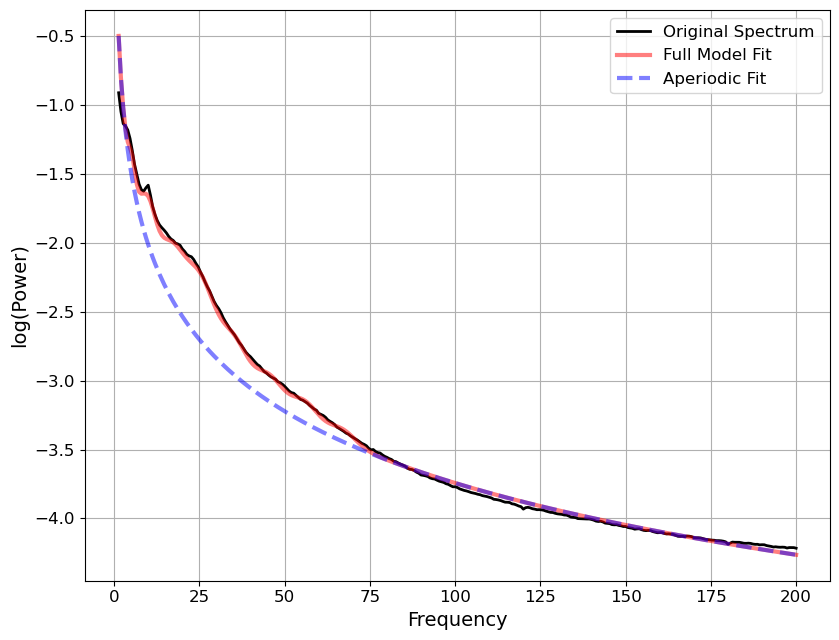

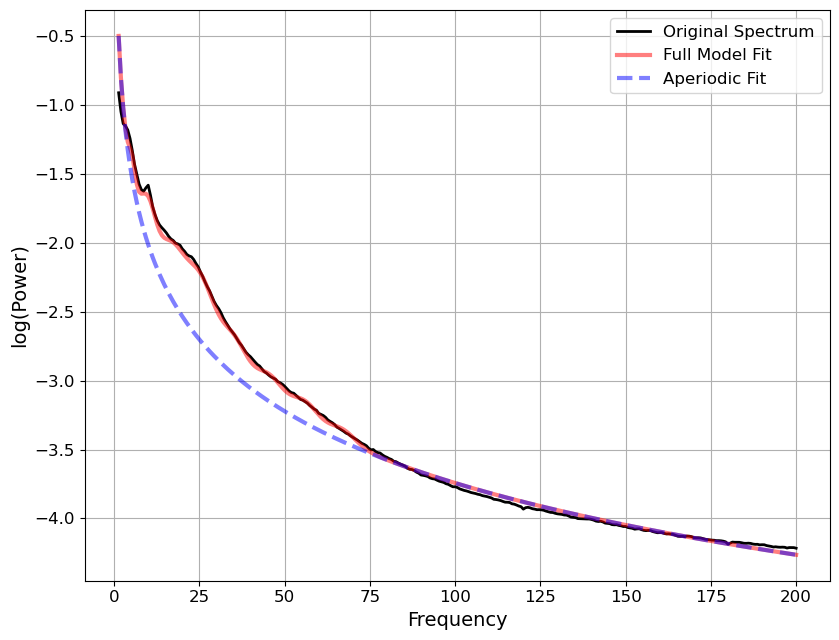

In [48]:
from fooof import FOOOF

# Initialize FOOOF model
fm = FOOOF(
    peak_width_limits=[1, 8],      # Min/max peak width in Hz
    max_n_peaks=8,                  # Max number of peaks to fit
    min_peak_height=0.1,            # Minimum peak height (in log power)
    peak_threshold=2.0,             # Relative threshold for peak detection
    aperiodic_mode='fixed'          # 'fixed' or 'knee' for aperiodic component
)

# Fit the model
# freq_range: the frequency range to fit (typically exclude very low freqs)
fm.fit(freqs, mean_psd, freq_range=[1, 200])

# View results
fm.report()  # Prints summary and shows plot

# Access specific components
print("Aperiodic parameters:", fm.aperiodic_params_)  # [offset, exponent] or [offset, knee, exponent]
print("Peak parameters:", fm.peak_params_)            # [center_freq, power, bandwidth] for each peak
print("R-squared:", fm.r_squared_)
print("Error:", fm.error_)

# Plot results
fm.plot()
plt.show()

# Get the aperiodic and periodic components separately
aperiodic_fit = fm.get_model('aperiodic')  # Just the 1/f component
full_model = fm.get_model('full')          # Full fitted model
periodic_fit = full_model - aperiodic_fit  # Just the peaks

R2: 0.9978 | Error: 0.0227
Number of peaks detected: 7
Max periodic deviation (log10 power): 0.498317


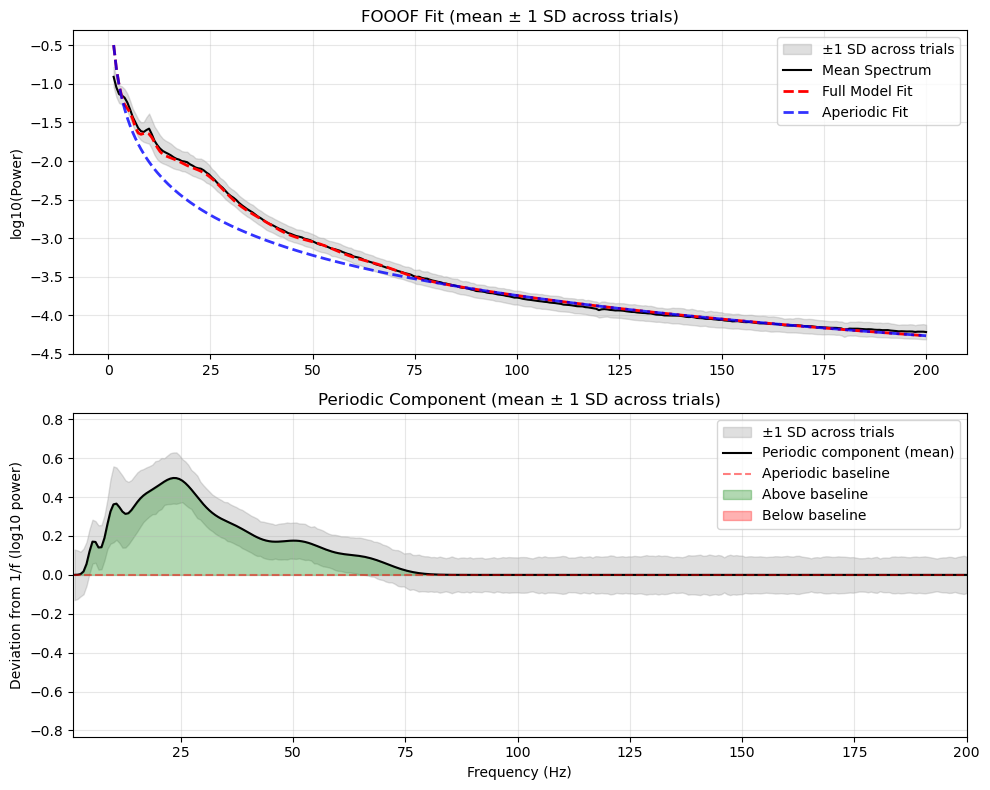


Detected peaks:
  Peak 1: 5.5 Hz (power: 0.1710, bandwidth: 2.0 Hz)
  Peak 2: 9.8 Hz (power: 0.3626, bandwidth: 3.4 Hz)
  Peak 3: 14.7 Hz (power: 0.3543, bandwidth: 6.7 Hz)
  Peak 4: 23.3 Hz (power: 0.4983, bandwidth: 11.4 Hz)
  Peak 5: 36.4 Hz (power: 0.2599, bandwidth: 12.0 Hz)
  Peak 6: 51.2 Hz (power: 0.1748, bandwidth: 12.0 Hz)
  Peak 7: 65.3 Hz (power: 0.0954, bandwidth: 12.0 Hz)


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from fooof import FOOOF

# Use freqs_ref / mean_psd from Cell 15
freqs_all = freqs_ref
psd_all   = mean_psd

# Restrict arrays to the fitting band
fit_mask   = (freqs_all >= 1) & (freqs_all <= 200)
freqs_fit  = freqs_all[fit_mask]
psd_fit    = psd_all[fit_mask]

# Compute SD across trials in log10 space (uses trial_psds list from Cell 15)
trial_psds_arr   = np.array(trial_psds)          # shape: (n_trials, n_freqs)
trial_psds_fit   = trial_psds_arr[:, fit_mask]    # restrict to fit band
log_trial_psds   = np.log10(trial_psds_fit)       # log10 of each trial
std_log_psd      = np.std(log_trial_psds, axis=0) # SD across trials in log space

# Fit FOOOF
fm = FOOOF(
    peak_width_limits=[2, 12],
    max_n_peaks=8,
    min_peak_height=0.02,
    peak_threshold=1.5,
    aperiodic_mode='fixed',
)
fm.fit(freqs_fit, psd_fit)

# Internal FOOOF arrays (all in log10 power, same length as freqs_fit)
log_psd      = np.log10(psd_fit)
log_full     = fm.fooofed_spectrum_
log_aperiodic = fm._ap_fit
periodic_log = fm._peak_fit

print(f'R2: {fm.r_squared_:.4f} | Error: {fm.error_:.4f}')
print(f'Number of peaks detected: {fm.n_peaks_}')
print(f'Max periodic deviation (log10 power): {np.max(np.abs(periodic_log)):.6f}')

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# ── Top: observed ± SD + model fits ──────────────────────────────────────────
axes[0].fill_between(
    freqs_fit,
    log_psd - std_log_psd,
    log_psd + std_log_psd,
    color='gray', alpha=0.25, label='±1 SD across trials',
)
axes[0].plot(freqs_fit, log_psd,     'k-',  label='Mean Spectrum',  linewidth=1.5)
axes[0].plot(freqs_fit, log_full,    'r--', label='Full Model Fit', linewidth=2)
axes[0].plot(freqs_fit, log_aperiodic, 'b--', label='Aperiodic Fit', linewidth=2, alpha=0.8)
axes[0].set_ylabel('log10(Power)')
axes[0].set_title('FOOOF Fit (mean ± 1 SD across trials)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Bottom: periodic component ± SD ──────────────────────────────────────────
# SD of individual-trial deviations from the aperiodic fit
trial_periodic = log_trial_psds - log_aperiodic[np.newaxis, :]
std_periodic   = np.std(trial_periodic, axis=0)

axes[1].fill_between(
    freqs_fit,
    periodic_log - std_periodic,
    periodic_log + std_periodic,
    color='gray', alpha=0.25, label='±1 SD across trials',
)
axes[1].plot(freqs_fit, periodic_log, 'k-', linewidth=1.5, label='Periodic component (mean)')
axes[1].axhline(0, color='r', linestyle='--', alpha=0.5, label='Aperiodic baseline')
axes[1].fill_between(freqs_fit, 0, periodic_log, where=(periodic_log > 0), alpha=0.3, color='green', label='Above baseline')
axes[1].fill_between(freqs_fit, 0, periodic_log, where=(periodic_log < 0), alpha=0.3, color='red',   label='Below baseline')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Deviation from 1/f (log10 power)')
axes[1].set_title('Periodic Component (mean ± 1 SD across trials)')
axes[1].set_xlim(1, 200)
axes[1].legend()
axes[1].grid(alpha=0.3)

peak_amp = np.max(np.abs(periodic_log))
ylim = max(0.01, 1.2 * (peak_amp + np.max(std_periodic)))
axes[1].set_ylim(-ylim, ylim)

plt.tight_layout()
plt.show()

if fm.n_peaks_ == 0:
    print('No peaks detected. Heavy averaging can flatten oscillatory peaks.')
else:
    print('\nDetected peaks:')
    for i, (cf, pw, bw) in enumerate(fm.peak_params_):
        print(f'  Peak {i+1}: {cf:.1f} Hz (power: {pw:.4f}, bandwidth: {bw:.1f} Hz)')

Processed 366 full continuous trials (State 3).


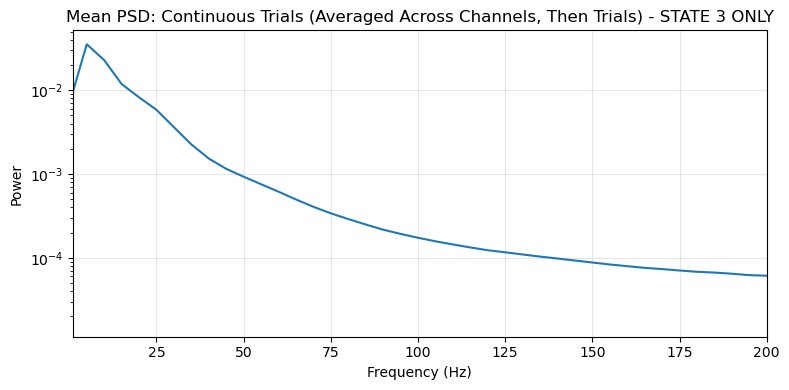

In [5]:
# Data already loaded earlier in your notebook
all_data = all_long_combined  # or short_data

fs = 1000
n_channels = 128
nperseg = 200 # 1.5-second Welch window for better than 1Hz resolution

all_trial_psds = [] 
freqs_ref = None

for subj_files in all_data.values():
    for mat_file in subj_files.values():
        broadband = mat_file.get("BroadbandData")
        task_state = mat_file.get("TaskState")

        
        # We need both arrays to proceed
        if broadband is None or task_state is None:
            continue
            
        # TaskState might be 2D in MATLAB (e.g., shape (N, 1)), so let's guarantee it's a flat 1D list 
        task_state_flat = np.array(task_state).flatten()

        # Filter out bins that do NOT correspond to State 3
        state_3_bins = []
        for i in range(len(broadband)):
            if task_state_flat[i] == 3:
                state_3_bins.append(broadband[i])
            
        # 1. CONCATENATE all the State 3 bins together into ONE continuous trial.
        full_trial_signal = np.concatenate(state_3_bins, axis=1) 
                    
        # 2. Calculate PSD on the full concatenated trial (for each channel)
        ch_psds = []
        for ch in range(n_channels):
                
            freqs, psd = welch(full_trial_signal[ch], fs=fs, nperseg=nperseg)
            ch_psds.append(psd)
            
        # If the trial was too short for Welch and ch_psds is empty, skip
        if len(ch_psds) == 0:
            continue
            
        # 3. Average across all 128 channels for THIS single trial
        trial_mean_psd = np.mean(ch_psds, axis=0) 
        all_trial_psds.append(trial_mean_psd)
        
        if freqs_ref is None:
            freqs_ref = freqs

print(f"Processed {len(all_trial_psds)} full continuous trials (State 3).")

# 4. Average across all trials to get final spectrum
mean_psd = np.mean(all_trial_psds, axis=0)

# Overwrite trial_psds so the FOOOF ±1 SD cell directly below continues to work!
trial_psds = all_trial_psds 

plt.figure(figsize=(8, 4))
plt.semilogy(freqs_ref, mean_psd)
plt.xlim(1, 200)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Mean PSD: Continuous Trials (Averaged Across Channels, Then Trials) - STATE 3 ONLY")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Fitting FOOOF from 1 to 200 Hz...

FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 2.00 <= 5.00
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

R2: 0.9972 | Error: 0.0337
Number of peaks detected: 3


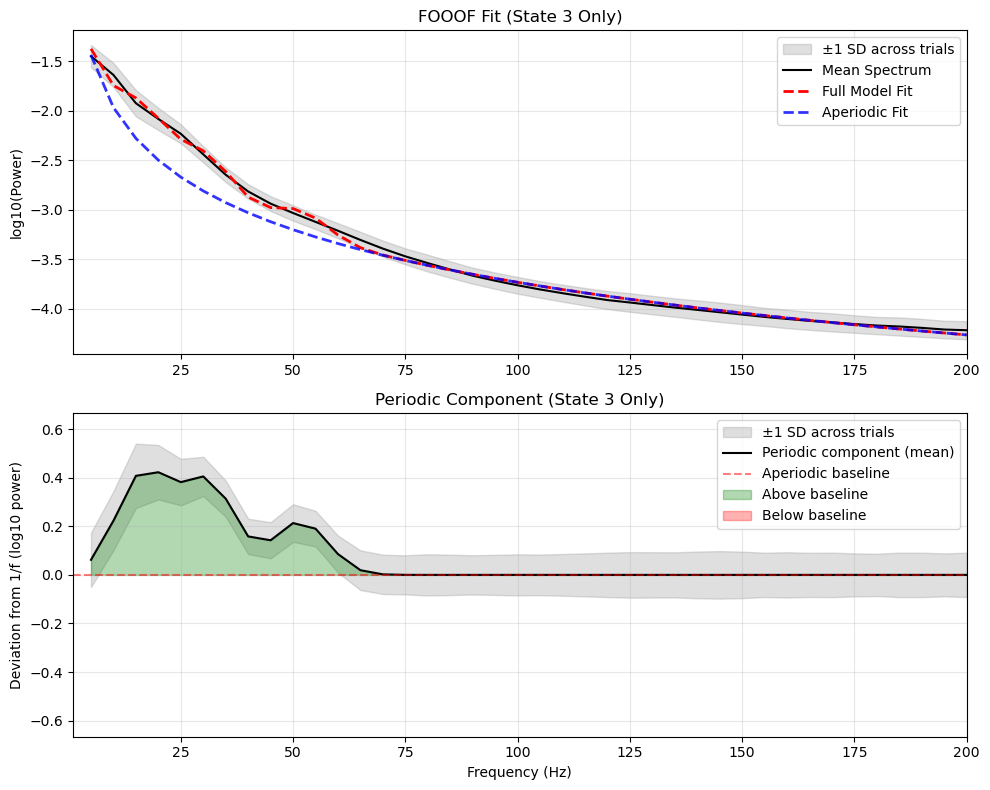


Detected peaks:
  Peak 1: CF=16.7 Hz, Power=0.4076, Bandwidth=12.0 Hz
  Peak 2: CF=31.1 Hz, Power=0.4051, Bandwidth=12.0 Hz
  Peak 3: CF=51.8 Hz, Power=0.2133, Bandwidth=12.0 Hz


In [6]:

def fit_and_plot_fooof(freqs, mean_psd, trial_psds=None, freq_range=(1, 200), title_suffix=""):
    """
    Fits a FOOOF model to an averaged PSD and optionally plots standard deviation 
    error bands if individual trial PSDs are provided.
    
    Parameters:
    - freqs (1D array): Frequency values from Welch.
    - mean_psd (1D array): The fully averaged PSD.
    - trial_psds (list or 2D array, optional): Un-averaged PSDs for each trial to calculate ±1 SD.
    - freq_range (tuple): The frequency band to fit (default is [1, 200]).
    - title_suffix (str): Text to append to the graph titles (e.g. " - State 3").
    """
    # 1. Restrict arrays to the specified fitting band
    fit_mask = (freqs >= freq_range[0]) & (freqs <= freq_range[1])
    freqs_fit = freqs[fit_mask]
    psd_fit = mean_psd[fit_mask]
    
    # Calculate SD across trials in log10 space if provided
    has_trials = trial_psds is not None and len(trial_psds) > 0
    if has_trials:
        trial_psds_arr = np.array(trial_psds)
        trial_psds_fit = trial_psds_arr[:, fit_mask]
        log_trial_psds = np.log10(trial_psds_fit)
        std_log_psd = np.std(log_trial_psds, axis=0)
    else:
        log_trial_psds = None
        std_log_psd = np.zeros_like(psd_fit)
        
    # 2. Init and Fit FOOOF
    print(f"Fitting FOOOF from {freq_range[0]} to {freq_range[1]} Hz...")
    fm = FOOOF(
        peak_width_limits=[2, 12],
        max_n_peaks=8,
        min_peak_height=0.02,
        peak_threshold=1.5,
        aperiodic_mode='fixed'
    )
    fm.fit(freqs_fit, psd_fit)
    
    # 3. Extract Internal FOOOF arrays (in log10 power)
    log_psd = np.log10(psd_fit)
    log_full = fm.fooofed_spectrum_
    log_aperiodic = fm._ap_fit
    periodic_log = fm._peak_fit
    
    print(f'R2: {fm.r_squared_:.4f} | Error: {fm.error_:.4f}')
    print(f'Number of peaks detected: {fm.n_peaks_}')
    
    # 4. Visualization
    fig, axes = plt.subplots(2, 1, figsize=(10, 8))
    
    # ── Top: observed ± SD + model fits ──
    if has_trials:
        axes[0].fill_between(freqs_fit, log_psd - std_log_psd, log_psd + std_log_psd,
                             color='gray', alpha=0.25, label='±1 SD across trials')
    axes[0].plot(freqs_fit, log_psd, 'k-', label='Mean Spectrum', linewidth=1.5)
    axes[0].plot(freqs_fit, log_full, 'r--', label='Full Model Fit', linewidth=2)
    axes[0].plot(freqs_fit, log_aperiodic, 'b--', label='Aperiodic Fit', linewidth=2, alpha=0.8)
    axes[0].set_ylabel('log10(Power)')
    axes[0].set_title(f'FOOOF Fit{title_suffix}')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[0].set_xlim(freq_range)

    # ── Bottom: periodic component ± SD ──
    if has_trials:
        trial_periodic = log_trial_psds - log_aperiodic[np.newaxis, :]
        std_periodic = np.std(trial_periodic, axis=0)
        axes[1].fill_between(freqs_fit, periodic_log - std_periodic, periodic_log + std_periodic,
                             color='gray', alpha=0.25, label='±1 SD across trials')
    else:
        std_periodic = np.zeros_like(periodic_log)

    axes[1].plot(freqs_fit, periodic_log, 'k-', linewidth=1.5, label='Periodic component (mean)')
    axes[1].axhline(0, color='r', linestyle='--', alpha=0.5, label='Aperiodic baseline')
    axes[1].fill_between(freqs_fit, 0, periodic_log, where=(periodic_log > 0), alpha=0.3, color='green', label='Above baseline')
    axes[1].fill_between(freqs_fit, 0, periodic_log, where=(periodic_log < 0), alpha=0.3, color='red', label='Below baseline')
    axes[1].set_xlabel('Frequency (Hz)')
    axes[1].set_ylabel('Deviation from 1/f (log10 power)')
    axes[1].set_title(f'Periodic Component{title_suffix}')
    axes[1].set_xlim(freq_range)
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    # Auto-scale y-axis on bottom plot
    peak_amp = np.max(np.abs(periodic_log))
    ylim = max(0.01, 1.2 * (peak_amp + np.max(std_periodic)))
    axes[1].set_ylim(-ylim, ylim)

    plt.tight_layout()
    plt.show()

    if fm.n_peaks_ > 0:
        print('\nDetected peaks:')
        for i, (cf, pw, bw) in enumerate(fm.peak_params_):
            print(f'  Peak {i+1}: CF={cf:.1f} Hz, Power={pw:.4f}, Bandwidth={bw:.1f} Hz')
            
    return fm

# ==========================================
# Run the function on the exact data you just extracted!
# ==========================================
fm_state3 = fit_and_plot_fooof(freqs_ref, mean_psd, trial_psds, freq_range=(1, 200), title_suffix=" (State 3 Only)")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# Since SmoothedNeuralFeatures is already band-power extracted from the raw data,
# we need to get the "BroadbandData" to calculate a true PSD of the preprocessed time-series.
# Let's extract the BroadbandData from the first trial in our dataset.

session_keys = list(all_long_combined.keys())
found_data = False

for key in session_keys:
    mat_files_dict = all_long_combined[key]
    first_mat_file_key = list(mat_files_dict.keys())[0]
    mat_file = mat_files_dict[first_mat_file_key]
    
    if 'BroadbandData' in mat_file:
        # BroadbandData is usually stored differently. We check if it's a list/array
        bb_data = mat_file['BroadbandData']
        if isinstance(bb_data, list) or hasattr(bb_data, '__iter__'):
            bb_segment = np.array(bb_data[0]) 
        else:
            bb_segment = np.array(bb_data)
        
        # Verify it has data
        if bb_segment.size > 0:
            found_data = True
            break

if found_data:
    # Ensure it's a 1D array for Welch's PSD calculation.
    # Usually shape is (Channels, Time)
    ch_idx = 0
    if bb_segment.ndim > 1:
        raw_signal = bb_segment[ch_idx, :]
    else:
        raw_signal = bb_segment

    # Adjust to your system's underlying preprocessing/raw sampling rate
    # E.g., if UpdateRate is 10Hz but features extracted from 500Hz/1000Hz raw
    fs_raw = 500 

    freqs, psd = welch(raw_signal, fs=fs_raw, nperseg=fs_raw*2) # 0.5Hz resolution

    plt.figure(figsize=(10, 6))
    plt.semilogy(freqs, psd, color='darkred', linewidth=1.5)

    plt.title(f'Power Spectral Density of Preprocessed BroadbandData (Ch {ch_idx+1})')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Power Spectral Density [Log Scale]')
    plt.xlim(0, 150) # Focusing on 0-150Hz
    plt.grid(True, which="both", ls="--", alpha=0.3)
    plt.show()
else:
    print("Could not find 'BroadbandData' to compute preprocessed PSD.")